### Divisão do dataset em treino/validação/teste

In [1]:
import os
import random
import shutil
from pathlib import Path

random.seed(42)

BASE = Path.cwd()  # pasta onde o script roda (reciclaAI/)
RAW = BASE / "raw_trashnet"
OUT = BASE / "reciclaAI_dataset"

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# proporções
train_frac = 0.70
val_frac = 0.15
test_frac = 0.15

assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6


def is_image_file(fn):
  return fn.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}


# cria pastas
for split in ["train", "val", "test"]:
  for c in CLASSES:
    (OUT / split / c).mkdir(parents=True, exist_ok=True)

summary = {}

for c in CLASSES:
  src_dir = RAW / c
  if not src_dir.exists():
    print(f"[AVISO] pasta {src_dir} não encontrada - classe {c} pulada")
    continue

  imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image_file(p)]
  random.shuffle(imgs)
  n = len(imgs)
  n_train = int(train_frac * n)
  n_val = int(val_frac * n)
  # garantimos que todas somem
  n_test = n - n_train - n_val

  train_imgs = imgs[:n_train]
  val_imgs = imgs[n_train : n_train + n_val]
  test_imgs = imgs[n_train + n_val :]

  for p in train_imgs:
    shutil.copy(p, OUT / "train" / c / p.name)
  for p in val_imgs:
    shutil.copy(p, OUT / "val" / c / p.name)
  for p in test_imgs:
    shutil.copy(p, OUT / "test" / c / p.name)

  summary[c] = {"total": n, "train": len(train_imgs), "val": len(val_imgs), "test": len(test_imgs)}

print("\nResumo por classe:")
total_all = 0
for c, v in summary.items():
  print(f" {c}: total={v['total']}  train={v['train']}  val={v['val']}  test={v['test']}")
  total_all += v["total"]
print(f"\nTotal de imagens: {total_all}")
print(f"Dataset criado em: {OUT.resolve()}")


Resumo por classe:
 cardboard: total=403  train=282  val=60  test=61
 glass: total=501  train=350  val=75  test=76
 metal: total=410  train=287  val=61  test=62
 paper: total=594  train=415  val=89  test=90
 plastic: total=482  train=337  val=72  test=73
 trash: total=137  train=95  val=20  test=22

Total de imagens: 2527
Dataset criado em: C:\Users\Agenor Evaristo\Desktop\SIC\Projeto\reciclaAI_dataset


### Treino do modelo

Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 513ms/step - accuracy: 0.7186 - loss: 0.7599 - val_accuracy: 0.8408 - val_loss: 0.5588
Epoch 12/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7429 - loss: 0.7025

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 523ms/step - accuracy: 0.7441 - loss: 0.7103 - val_accuracy: 0.8435 - val_loss: 0.5444
Epoch 13/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7539 - loss: 0.6811

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 518ms/step - accuracy: 0.7542 - loss: 0.6826 - val_accuracy: 0.8435 - val_loss: 0.5379
Epoch 14/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7377 - loss: 0.7040

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 514ms/step - accuracy: 0.7469 - loss: 0.6823 - val_accuracy: 0.8408 - val_loss: 0.5246
Epoch 15/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7729 - loss: 0.6682

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 511ms/step - accuracy: 0.7531 - loss: 0.6873 - val_accuracy: 0.8223 - val_loss: 0.5159
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - accuracy: 0.7682 - loss: 0.6124

 Acurácia no conjunto de teste: 0.7682
 Loss no conjunto de teste: 0.6124


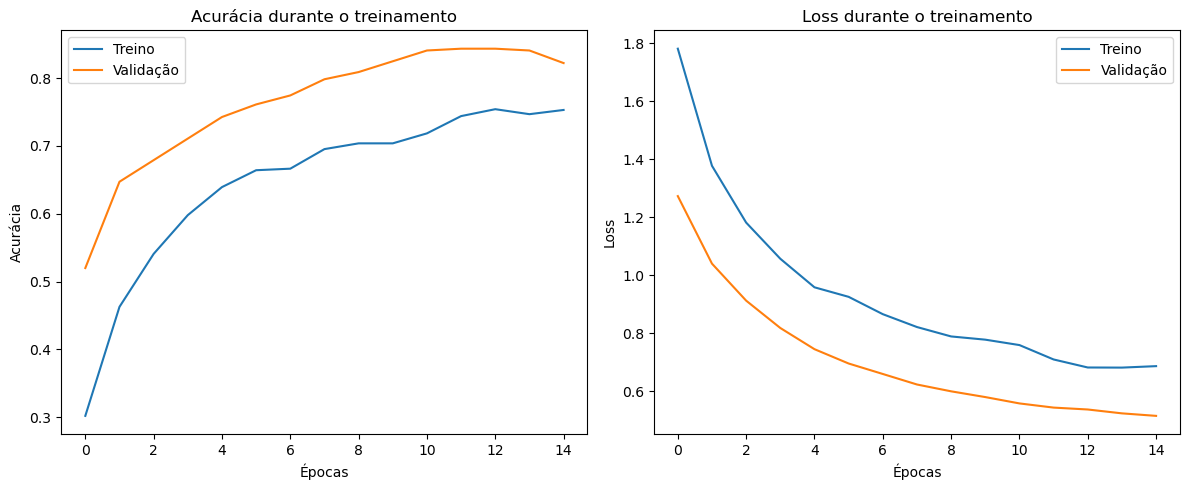


 Modelo salvo como reciclaAI_model_final


In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definições gerais
DATASET_DIR = "reciclaAI_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4  # taxa de aprendizado

# classes
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
NUM_CLASSES = len(CLASSES)


# Preparação do dataset
train_datagen = ImageDataGenerator(
  rescale=1.0 / 255,
  rotation_range=30,
  width_shift_range=0.15,
  height_shift_range=0.15,
  zoom_range=0.15,
  horizontal_flip=True,
  fill_mode="nearest",
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
  os.path.join(DATASET_DIR, "train"), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
  os.path.join(DATASET_DIR, "val"), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
  os.path.join(DATASET_DIR, "test"),
  target_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  class_mode="categorical",
  shuffle=False,
)


# Construção do modelo baseado no MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # congela pesos do modelo base

model = Sequential(
  [
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax"),
  ]
)

model.compile(optimizer=Adam(learning_rate=LR), loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()


callbacks = [
  EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
  ModelCheckpoint("reciclaAI_best_model.h5", save_best_only=True),
]


# Treinamento
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)


# Avaliação
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n Acurácia no conjunto de teste: {test_acc:.4f}")
print(f" Loss no conjunto de teste: {test_loss:.4f}")


# Gráficos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Loss durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# SALVAR MODELO FINAL
model.save("reciclaAI_model_final.h5")
print("\n Modelo salvo como reciclaAI_model_final")